DATA INSPECTION 

C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\MY PROJECT E PAARVAI\
│
├── Cataract v01.v7i.folder\
│   └── train\
│       ├── immature\
│       ├── mature\
│       └── normal\
│
├── Dataset Katarak\
│   ├── train\
│   │   ├── immature\
│   │   ├── mature\
│   │   └── normal\
│   └── test\
│       ├── immature\
│       ├── mature\
│       └── normal\
│
└── SLID\
    ├── Annotations.csv
    └── Original_Slit-lamp_Images\
        └── Original_Slit-lamp_Images\
            ├── 1.png
            ├── 2.png
            └── ...
            

 first I will only inspect the data.I will not move/delete/rename anything.

In [1]:
from pathlib import Path
import pandas as pd
from collections import Counter

ROOT = Path(
    r"C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\MY PROJECT E PAARVAI"
)

CATARACT_V01 = ROOT / "Cataract v01.v7i.folder"
KATARAK = ROOT / "Dataset Katarak"

SLID = ROOT / "SLID"
SLID_IMAGES = (
    SLID
    / "Original_Slit-lamp_Images"
    / "Original_Slit-lamp_Images"
)
SLID_CSV = SLID / "Annotations.csv"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def count_images(folder):
    if not folder.exists():
        return 0

    return sum(
        1
        for file in folder.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    )


print("NETRASCAN DATASET CHECK")
print("=" * 50)

paths = {
    "Cataract v01": CATARACT_V01,
    "Dataset Katarak": KATARAK,
    "SLID images": SLID_IMAGES,
    "SLID annotations": SLID_CSV
}

for name, path in paths.items():
    print(f"{name:20} : {'FOUND' if path.exists() else 'NOT FOUND'}")

print("\nIMAGE COUNTS")
print("=" * 50)

print("Cataract v01 :", count_images(CATARACT_V01))
print("Dataset Katarak :", count_images(KATARAK))
print("SLID :", count_images(SLID_IMAGES))

print("\nSLID CSV")
print("=" * 50)

if SLID_CSV.exists():
    slid_df = pd.read_csv(SLID_CSV)

    print("Rows:", len(slid_df))
    print("Columns:")
    print(list(slid_df.columns))

    display(slid_df.head())

NETRASCAN DATASET CHECK
Cataract v01         : FOUND
Dataset Katarak      : FOUND
SLID images          : FOUND
SLID annotations     : FOUND

IMAGE COUNTS
Cataract v01 : 587
Dataset Katarak : 2955
SLID : 2617

SLID CSV
Rows: 10204
Columns:
['filename', 'file_size', 'annotation_count', 'annotation_ID', 'attributes', 'shape_coordinates']


,filename,file_size,annotation_count,annotation_ID,attributes,shape_coordinates
0,1.png,104027,3,0,"{""region"":""Pupil"",""lesion"":""""}","{""name"":""circle"",""cx"":685,""cy"":468,""r"":165}"
1,1.png,104027,3,1,"{""region"":""Cornea"",""lesion"":""""}","{""name"":""circle"",""cx"":661,""cy"":488,""r"":427}"
2,1.png,104027,3,2,"{""region"":""Conjunctiva"",""lesion"":""""}","{""name"":""polygon"",""all_points_x"":[378,308,168,..."
3,2.png,103678,3,0,"{""region"":""Pupil"",""lesion"":""""}","{""name"":""circle"",""cx"":682,""cy"":466,""r"":154}"
4,2.png,103678,3,1,"{""region"":""Cornea"",""lesion"":""""}","{""name"":""circle"",""cx"":661,""cy"":482,""r"":437}"


Cell 2 — inspect exact class distribution

In [2]:
import ast
from collections import Counter

print("NETRASCAN CLASS DISTRIBUTION")
print("=" * 60)


# --------------------------------------------------
# 1. CATARACT V01
# --------------------------------------------------

print("\nCATARACT V01")
print("-" * 60)

v01_train = CATARACT_V01 / "train"

for class_name in ["normal", "immature", "mature"]:
    folder = v01_train / class_name

    print(
        f"{class_name.capitalize():15}: "
        f"{count_images(folder)} images"
    )


# --------------------------------------------------
# 2. DATASET KATARAK
# --------------------------------------------------

print("\nDATASET KATARAK")
print("-" * 60)

for split in ["train", "test"]:

    print(f"\n{split.upper()}")

    split_total = 0

    for class_name in ["normal", "immature", "mature"]:

        folder = KATARAK / split / class_name
        n = count_images(folder)

        split_total += n

        print(
            f"{class_name.capitalize():15}: "
            f"{n} images"
        )

    print(f"{'Total':15}: {split_total} images")


# --------------------------------------------------
# 3. SLID
# --------------------------------------------------

print("\nSLID")
print("-" * 60)


def extract_lesion(attribute):

    try:
        data = ast.literal_eval(str(attribute))

        lesion = str(
            data.get("lesion", "")
        ).strip()

        return lesion

    except:
        return ""


slid_df["lesion"] = slid_df["attributes"].apply(
    extract_lesion
)


# Count UNIQUE images for each lesion
lesion_image_counts = (
    slid_df[
        slid_df["lesion"] != ""
    ]
    .groupby("lesion")["filename"]
    .nunique()
    .sort_values(ascending=False)
)


print("\nSLID lesion labels:\n")

print(lesion_image_counts.to_string())


# --------------------------------------------------
# IMPORTANT NETRASCAN LABELS
# --------------------------------------------------

print("\n" + "=" * 60)
print("NETRASCAN-RELEVANT SLID LABELS")
print("=" * 60)


def count_slid_images_with_lesion(keyword):

    mask = slid_df["lesion"].str.contains(
        keyword,
        case=False,
        na=False
    )

    return slid_df.loc[
        mask,
        "filename"
    ].nunique()


print(
    "Cataract:",
    count_slid_images_with_lesion("cataract")
)

print(
    "Intraocular Lens:",
    count_slid_images_with_lesion("intraocular")
)


# --------------------------------------------------
# NORMAL SLID IMAGES
# --------------------------------------------------

all_slid_images = set(
    slid_df["filename"].unique()
)

images_with_lesions = set(
    slid_df.loc[
        slid_df["lesion"] != "",
        "filename"
    ].unique()
)

normal_slid_images = (
    all_slid_images - images_with_lesions
)


print(
    "No lesion / Normal:",
    len(normal_slid_images)
)

NETRASCAN CLASS DISTRIBUTION

CATARACT V01
------------------------------------------------------------
Normal         : 184 images
Immature       : 211 images
Mature         : 192 images

DATASET KATARAK
------------------------------------------------------------

TRAIN
Normal         : 820 images
Immature       : 820 images
Mature         : 820 images
Total          : 2460 images

TEST
Normal         : 165 images
Immature       : 165 images
Mature         : 165 images
Total          : 495 images

SLID
------------------------------------------------------------

SLID lesion labels:

lesion
Corneal / Conjunctival tumor    488
Pigmented nevus                 416
Pinguecula                      405
Conjunctival injection          307
Corneal dystrophy               300
Keratitis                       222
Cataract                        221
Subconjunctival hemorrhage      181
Pterygium                       163
Intraocular lens                119
Conjunctival cyst               113
Corn

NOW I KNOW THE RAW DISTRIBUTION. I do not take 1,414 / 1,196 / 1,177 as our final dataset counts yet. Cataract v01 may overlap with Katarak, and Cataract v01 itself contains augmentation-generated images. Deduplication comes first.

I should not put those 4 Lens dislocation/Cataract images into ordinary cataract severity classes. And the remaining 221 are generic cataract—not reliably immature/mature—so for now we're keeping them outside the primary severity training set.
The 119 Intraocular Lens images are our candidate source for the fourth PC-IOL / Pseudophakia class. 
But even those should be checked carefully before training because SLID is slit-lamp imagery whereas the other sources may have different acquisition characteristics. 
Otherwise the network could learn “SLID-looking image = IOL” instead of actually learning the IOL.

MY tentative four-class dataset would be very imbalanced:And those numbers will change after deduplication.
So I will not solve this by copying IOL images until we have 1,000. Later we'll consider weighted loss, balanced sampling, augmentation, and ideally more legitimate IOL data.

master metadata: Now I create one row per image containing its source, original split, class, path, etc. I am still not modifying any images.
describing existing real images i create one row per image containing its source, original split, class, path, etc. i am still not modifying any images.

In [3]:
from pathlib import Path
import pandas as pd

records = []


# ============================================================
# 1. CATARACT V01
# ============================================================

for class_name in ["normal", "immature", "mature"]:

    folder = CATARACT_V01 / "train" / class_name

    for image_path in folder.iterdir():

        if (
            image_path.is_file()
            and image_path.suffix.lower() in IMAGE_EXTENSIONS
        ):

            records.append({
                "source": "cataract_v01",
                "original_split": "train",
                "filename": image_path.name,
                "class": class_name,
                "original_label": class_name,
                "image_path": str(image_path),
                "modality": "anterior_eye",
                "use_for_primary_training": True
            })


# ============================================================
# 2. DATASET KATARAK
# ============================================================

for split in ["train", "test"]:

    for class_name in ["normal", "immature", "mature"]:

        folder = KATARAK / split / class_name

        for image_path in folder.iterdir():

            if (
                image_path.is_file()
                and image_path.suffix.lower() in IMAGE_EXTENSIONS
            ):

                records.append({
                    "source": "dataset_katarak",
                    "original_split": split,
                    "filename": image_path.name,
                    "class": class_name,
                    "original_label": class_name,
                    "image_path": str(image_path),
                    "modality": "anterior_eye",
                    "use_for_primary_training": True
                })


# ============================================================
# 3. SLID
# ============================================================

# One row per SLID image
for filename in sorted(all_slid_images):

    rows = slid_df[
        slid_df["filename"] == filename
    ]

    lesions = sorted(
        set(
            lesion
            for lesion in rows["lesion"]
            if lesion != ""
        )
    )

    lesions_lower = [
        lesion.lower()
        for lesion in lesions
    ]

    # --------------------------------------------
    # Determine NetraScan label
    # --------------------------------------------

    if len(lesions) == 0:

        netrascan_class = "normal"
        use_primary = False

    elif any(
        "intraocular lens" in lesion
        for lesion in lesions_lower
    ):

        netrascan_class = "pc_iol"
        use_primary = False

    elif any(
        "cataract" in lesion
        for lesion in lesions_lower
    ):

        netrascan_class = "generic_cataract"
        use_primary = False

    else:

        netrascan_class = "other_eye_condition"
        use_primary = False


    image_path = SLID_IMAGES / filename


    records.append({
        "source": "slid",
        "original_split": "unsplit",
        "filename": filename,
        "class": netrascan_class,
        "original_label": " | ".join(lesions) if lesions else "normal",
        "image_path": str(image_path),
        "modality": "slit_lamp",
        "use_for_primary_training": use_primary
    })


# ============================================================
# CREATE MASTER DATAFRAME
# ============================================================

metadata = pd.DataFrame(records)


print("MASTER METADATA CREATED")
print("=" * 60)

print("Total images:", len(metadata))

print("\nImages by source:")
print(metadata["source"].value_counts())

print("\nImages by NetraScan class:")
print(metadata["class"].value_counts())

print("\nSource × Class:")
display(
    pd.crosstab(
        metadata["source"],
        metadata["class"]
    )
)

print("\nPreview:")
display(metadata.head(10))

MASTER METADATA CREATED
Total images: 6159

Images by source:
source
dataset_katarak    2955
slid               2617
cataract_v01        587
Name: count, dtype: int64

Images by NetraScan class:
class
other_eye_condition    2028
normal                 1414
immature               1196
mature                 1177
generic_cataract        225
pc_iol                  119
Name: count, dtype: int64

Source × Class:


class,generic_cataract,immature,mature,normal,other_eye_condition,pc_iol
source,,,,,,
cataract_v01,0,211,192,184,0,0
dataset_katarak,0,985,985,985,0,0
slid,225,0,0,245,2028,119



Preview:


,source,original_split,filename,class,original_label,image_path,modality,use_for_primary_training
0,cataract_v01,train,10_JPG.rf.4d794597e5e669e1ef983f5a6f35c7be.jpg,normal,normal,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...,anterior_eye,True
1,cataract_v01,train,10_JPG.rf.82653827daeea8d76984332b12542e4c.jpg,normal,normal,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...,anterior_eye,True
2,cataract_v01,train,10_JPG_jpg.rf.3a69cc495f501d671f0eabbecb32f1fb...,normal,normal,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...,anterior_eye,True
3,cataract_v01,train,10_JPG_jpg.rf.6d4e8477b384db74b247556e1929949e...,normal,normal,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...,anterior_eye,True
4,cataract_v01,train,10_JPG_jpg.rf.f685ff537d35a314eafe627abfe5f545...,normal,normal,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...,anterior_eye,True
5,cataract_v01,train,11_JPG.rf.012e9da4323b3b425c4ddff190854340.jpg,normal,normal,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...,anterior_eye,True
6,cataract_v01,train,11_JPG.rf.bf2fd6d437a787ddc3192912f49f16b7.jpg,normal,normal,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...,anterior_eye,True
7,cataract_v01,train,11_JPG_jpg.rf.0c6f778623eadea084efc6bb05816f87...,normal,normal,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...,anterior_eye,True
8,cataract_v01,train,11_JPG_jpg.rf.21062af086181fdc1149f3e5b4ab236c...,normal,normal,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...,anterior_eye,True
9,cataract_v01,train,11_JPG_jpg.rf.c40ecc148d252c0c619e2d0b9b0bf1d7...,normal,normal,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...,anterior_eye,True


Exact duplicate detection: First I'll use SHA-256.
If two files have the same SHA-256 hash, their file contents are byte-for-byte identical.

In [4]:
import hashlib
from pathlib import Path
from collections import Counter


def calculate_sha256(image_path):

    sha256 = hashlib.sha256()

    try:
        with open(image_path, "rb") as file:

            while True:

                chunk = file.read(8192)

                if not chunk:
                    break

                sha256.update(chunk)

        return sha256.hexdigest()

    except Exception as e:

        print(
            f"ERROR: {image_path}\n"
            f"{e}\n"
        )

        return None


print("CALCULATING SHA-256 HASHES...")
print("=" * 60)


metadata["sha256"] = metadata["image_path"].apply(
    calculate_sha256
)


print("\nHashing complete.")

print(
    "Successfully hashed:",
    metadata["sha256"].notna().sum()
)

print(
    "Failed:",
    metadata["sha256"].isna().sum()
)


# ============================================================
# DUPLICATE ANALYSIS
# ============================================================

hash_counts = metadata["sha256"].value_counts()

duplicate_hashes = hash_counts[
    hash_counts > 1
]


duplicate_images = metadata[
    metadata["sha256"].isin(
        duplicate_hashes.index
    )
].copy()


print("\n" + "=" * 60)
print("EXACT DUPLICATE ANALYSIS")
print("=" * 60)

print(
    "Unique image hashes:",
    metadata["sha256"].nunique()
)

print(
    "Duplicate hash groups:",
    len(duplicate_hashes)
)

print(
    "Images belonging to duplicate groups:",
    len(duplicate_images)
)


# ============================================================
# DUPLICATES ACROSS SOURCES
# ============================================================

cross_source_groups = []


for image_hash, group in duplicate_images.groupby("sha256"):

    sources = group["source"].unique()

    if len(sources) > 1:

        cross_source_groups.append(
            {
                "sha256": image_hash,
                "number_of_images": len(group),
                "sources": " | ".join(sorted(sources)),
                "classes": " | ".join(
                    sorted(
                        group["class"].unique()
                    )
                )
            }
        )


cross_source_df = pd.DataFrame(
    cross_source_groups
)


print("\nCROSS-SOURCE DUPLICATES")
print("=" * 60)

print(
    "Duplicate groups appearing in multiple datasets:",
    len(cross_source_df)
)


if len(cross_source_df) > 0:

    display(
        cross_source_df.head(20)
    )


# ============================================================
# CHECK LABEL CONFLICTS
# ============================================================

label_conflicts = []


for image_hash, group in duplicate_images.groupby("sha256"):

    classes = group["class"].unique()

    if len(classes) > 1:

        label_conflicts.append(
            {
                "sha256": image_hash,
                "classes": " | ".join(
                    sorted(classes)
                ),
                "sources": " | ".join(
                    sorted(
                        group["source"].unique()
                    )
                ),
                "number_of_images": len(group)
            }
        )


label_conflicts_df = pd.DataFrame(
    label_conflicts
)


print("\nLABEL CONFLICTS")
print("=" * 60)

print(
    "Exact duplicate groups with different labels:",
    len(label_conflicts_df)
)


if len(label_conflicts_df) > 0:

    display(
        label_conflicts_df.head(20)
    )

CALCULATING SHA-256 HASHES...

Hashing complete.
Successfully hashed: 6159
Failed: 0

EXACT DUPLICATE ANALYSIS
Unique image hashes: 6159
Duplicate hash groups: 0
Images belonging to duplicate groups: 0

CROSS-SOURCE DUPLICATES
Duplicate groups appearing in multiple datasets: 0

LABEL CONFLICTS
Exact duplicate groups with different labels: 0


So All 6,159 files have unique byte-level contents.

perceptual duplicate detection
I'll use pHash (perceptual hashing). Unlike SHA-256, pHash is based on visual appearance.

In [5]:
!pip install ImageHash

   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------------------------- 4.2/4.2 MB 21.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [PyWavelets]
   ---------------------------------------- 0/2 [PyWavelets]
   ---------------------------------------- 0/2 [PyWavelets]
   -------------------- ------------------- 1/2 [ImageHash]
   ---------------------------------------- 2/2 [ImageHash]




[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from PIL import Image
import imagehash
from tqdm.auto import tqdm

tqdm.pandas()


def calculate_phash(image_path):
    try:
        with Image.open(image_path) as img:
            img = img.convert("RGB")
            return str(imagehash.phash(img))

    except Exception as e:
        print(f"ERROR: {image_path}")
        print(e)
        return None


print("CALCULATING PERCEPTUAL HASHES...")
print("=" * 60)

metadata["phash"] = metadata["image_path"].progress_apply(
    calculate_phash
)

print("\nPerceptual hashing complete.")

print(
    "Successfully hashed:",
    metadata["phash"].notna().sum()
)

print(
    "Failed:",
    metadata["phash"].isna().sum()
)


# ============================================================
# IDENTICAL PERCEPTUAL HASHES
# ============================================================

phash_counts = metadata["phash"].value_counts()

duplicate_phashes = phash_counts[
    phash_counts > 1
]

perceptual_duplicates = metadata[
    metadata["phash"].isin(
        duplicate_phashes.index
    )
].copy()


print("\n" + "=" * 60)
print("PERCEPTUAL DUPLICATE ANALYSIS")
print("=" * 60)

print(
    "Unique perceptual hashes:",
    metadata["phash"].nunique()
)

print(
    "Identical pHash groups:",
    len(duplicate_phashes)
)

print(
    "Images in identical pHash groups:",
    len(perceptual_duplicates)
)


# ============================================================
# CROSS-SOURCE pHASH DUPLICATES
# ============================================================

cross_source_phash = []

for phash_value, group in perceptual_duplicates.groupby("phash"):

    if group["source"].nunique() > 1:

        cross_source_phash.append({
            "phash": phash_value,
            "images": len(group),

            "sources": " | ".join(
                sorted(group["source"].unique())
            ),

            "classes": " | ".join(
                sorted(group["class"].unique())
            )
        })


cross_source_phash_df = pd.DataFrame(
    cross_source_phash
)


print("\nCROSS-SOURCE IDENTICAL pHASH")
print("=" * 60)

print(
    "Groups:",
    len(cross_source_phash_df)
)


if len(cross_source_phash_df) > 0:
    display(cross_source_phash_df.head(30))


# ============================================================
# LABEL CONFLICTS
# ============================================================

phash_label_conflicts = []

for phash_value, group in perceptual_duplicates.groupby("phash"):

    if group["class"].nunique() > 1:

        phash_label_conflicts.append({
            "phash": phash_value,

            "classes": " | ".join(
                sorted(group["class"].unique())
            ),

            "sources": " | ".join(
                sorted(group["source"].unique())
            ),

            "images": len(group)
        })


phash_conflict_df = pd.DataFrame(
    phash_label_conflicts
)


print("\npHASH LABEL CONFLICTS")
print("=" * 60)

print(
    "Groups with different labels:",
    len(phash_conflict_df)
)


if len(phash_conflict_df) > 0:
    display(phash_conflict_df.head(30))

CALCULATING PERCEPTUAL HASHES...


  0%|          | 0/6159 [00:00<?, ?it/s]


Perceptual hashing complete.
Successfully hashed: 6159
Failed: 0

PERCEPTUAL DUPLICATE ANALYSIS
Unique perceptual hashes: 5715
Identical pHash groups: 211
Images in identical pHash groups: 655

CROSS-SOURCE IDENTICAL pHASH
Groups: 39


,phash,images,sources,classes
0,8738bca770646796,7,cataract_v01 | dataset_katarak,mature
1,8939f0a63f989ac9,3,cataract_v01 | dataset_katarak,mature
2,a0383f2338cce7e9,5,cataract_v01 | dataset_katarak,mature
3,a1c1d62e8ebd9895,5,cataract_v01 | dataset_katarak,immature
4,a535de52588b7949,5,cataract_v01 | dataset_katarak,normal
5,a5699ede39983119,3,cataract_v01 | dataset_katarak,normal
6,a5d2ca2d2575b634,5,cataract_v01 | dataset_katarak,immature
7,aca9e194ca93dc8b,5,cataract_v01 | dataset_katarak,mature
8,aceaf3c4cc8a328b,3,cataract_v01 | dataset_katarak,mature
9,b21ec9390d74cea6,2,cataract_v01 | dataset_katarak,normal



pHASH LABEL CONFLICTS
Groups with different labels: 0


My results show:
- 6,159 total images
- 5,715 unique pHashes
- 211 identical-pHash groups
- 655 images belong to those groups
- 39 groups occur across Cataract v01 and Dataset Katarak
- 0 label conflicts 

So the two datasets do overlap visually, but when an overlapping image appears, its class label is consistent. That's reassuring.
Also, 655 does not mean I should delete 655 images. A duplicate group containing 5 images represents roughly 1 underlying visual sample plus 4 redundant variants. I haven't yet decided which ones to retain.

Original eye
↓
brightness changed
↓
slightly rotated
↓
cropped
↓
JPEG compressed

find near-duplicates S
ince 6,159² comparisons is manageable but unnecessary, I'll focus on the cataract severity datasets first: cataract_v01 and dataset_katarak.

In [7]:
import numpy as np
import imagehash
from tqdm.auto import tqdm


# ============================================================
# ONLY PRIMARY CATARACT DATASETS
# ============================================================

primary = metadata[
    metadata["source"].isin(
        ["cataract_v01", "dataset_katarak"]
    )
].copy().reset_index(drop=True)


print("Primary cataract images:", len(primary))


# Convert hexadecimal pHash to ImageHash objects
hash_objects = [
    imagehash.hex_to_hash(x)
    for x in primary["phash"]
]


# ============================================================
# FIND NEAR-DUPLICATES
# ============================================================

MAX_DISTANCE = 4

near_duplicate_pairs = []


print("\nSEARCHING FOR NEAR-DUPLICATES...")
print("Maximum pHash distance:", MAX_DISTANCE)
print("=" * 60)


for i in tqdm(range(len(primary))):

    hash_i = hash_objects[i]

    for j in range(i + 1, len(primary)):

        distance = hash_i - hash_objects[j]

        if distance <= MAX_DISTANCE:

            near_duplicate_pairs.append({
                "index_1": i,
                "index_2": j,

                "distance": distance,

                "source_1": primary.loc[i, "source"],
                "source_2": primary.loc[j, "source"],

                "class_1": primary.loc[i, "class"],
                "class_2": primary.loc[j, "class"],

                "filename_1": primary.loc[i, "filename"],
                "filename_2": primary.loc[j, "filename"],

                "path_1": primary.loc[i, "image_path"],
                "path_2": primary.loc[j, "image_path"]
            })


near_duplicates_df = pd.DataFrame(
    near_duplicate_pairs
)


print("\nSEARCH COMPLETE")
print("=" * 60)

print(
    "Near-duplicate pairs found:",
    len(near_duplicates_df)
)


if len(near_duplicates_df) > 0:

    print("\nDistance distribution:")

    print(
        near_duplicates_df[
            "distance"
        ].value_counts().sort_index()
    )


    print("\nCross-source near-duplicate pairs:")

    cross_source_near = near_duplicates_df[
        near_duplicates_df["source_1"]
        !=
        near_duplicates_df["source_2"]
    ]

    print(
        len(cross_source_near)
    )


    print("\nLabel-conflicting near-duplicate pairs:")

    conflicting_near = near_duplicates_df[
        near_duplicates_df["class_1"]
        !=
        near_duplicates_df["class_2"]
    ]

    print(
        len(conflicting_near)
    )


    if len(conflicting_near) > 0:

        display(
            conflicting_near[
                [
                    "distance",
                    "source_1",
                    "source_2",
                    "class_1",
                    "class_2",
                    "filename_1",
                    "filename_2"
                ]
            ].head(30)
        )

Primary cataract images: 3542

SEARCHING FOR NEAR-DUPLICATES...
Maximum pHash distance: 4


  0%|          | 0/3542 [00:00<?, ?it/s]


SEARCH COMPLETE
Near-duplicate pairs found: 1378

Distance distribution:
distance
0    875
2    235
4    268
Name: count, dtype: int64

Cross-source near-duplicate pairs:
169

Label-conflicting near-duplicate pairs:
1


,distance,source_1,source_2,class_1,class_2,filename_1,filename_2
1167,4,dataset_katarak,dataset_katarak,normal,immature,aug_0_5412_jpeg.rf.73e066efc4d3c5fe7d4ee282860...,aug_0_6041_jpeg.rf.d930ca3341ae372a2dd11bd4cfd...


Primary cataract images: 3,542
Candidate near-duplicate pairs (pHash distance ≤ 4): 1,378
Distance 0: 875 pairs
Distance 2: 235 pairs
Distance 4: 268 pairs
Cross-source pairs: 169
Different-label candidates: only 1

That last one is especially important. The pair is:
Dataset Katarak
Normal  ↔  Immature
pHash distance = 4

But do not conclude that it is mislabeled yet. A distance of 4 means visually similar, not necessarily the same image. Two eye photographs can legitimately look similar.
Before removing anything, let's visually inspect the suspicious pairs

LABEL-CONFLICTING PAIR


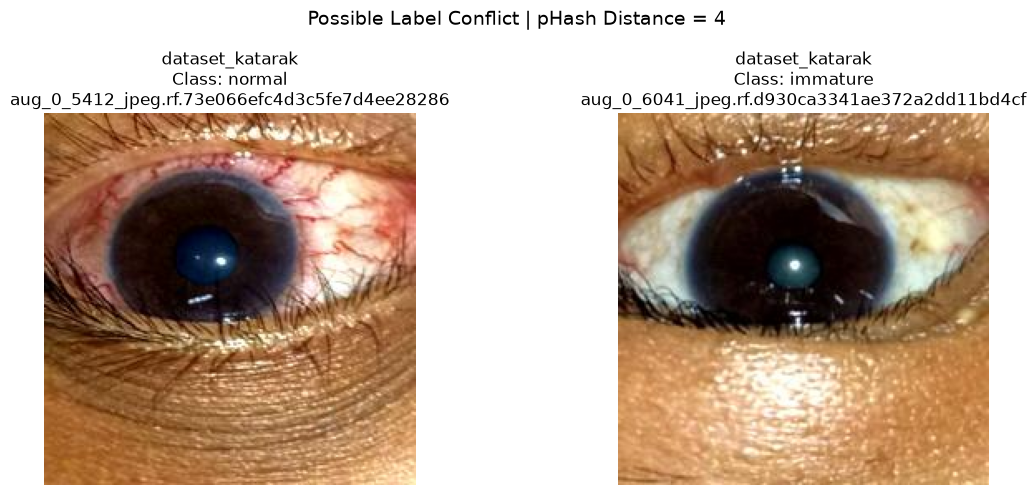


CROSS-SOURCE EXAMPLES


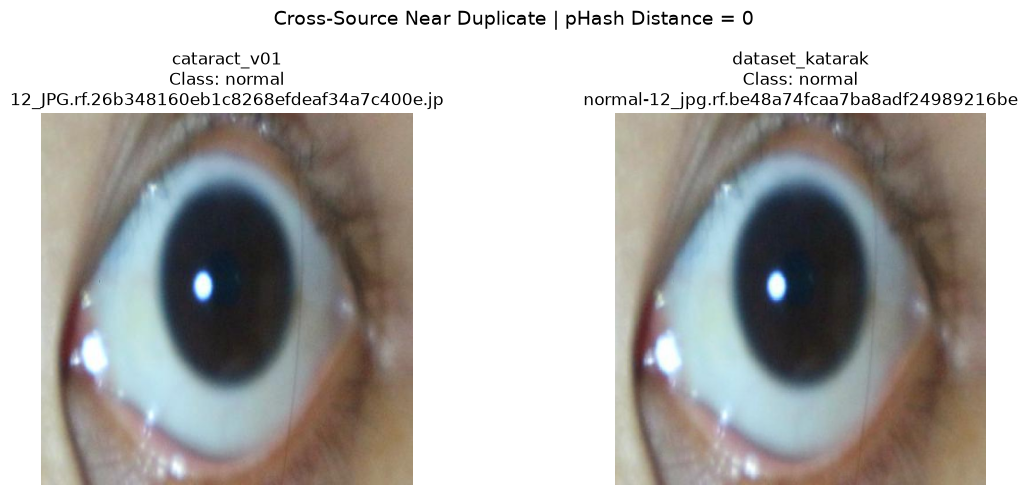

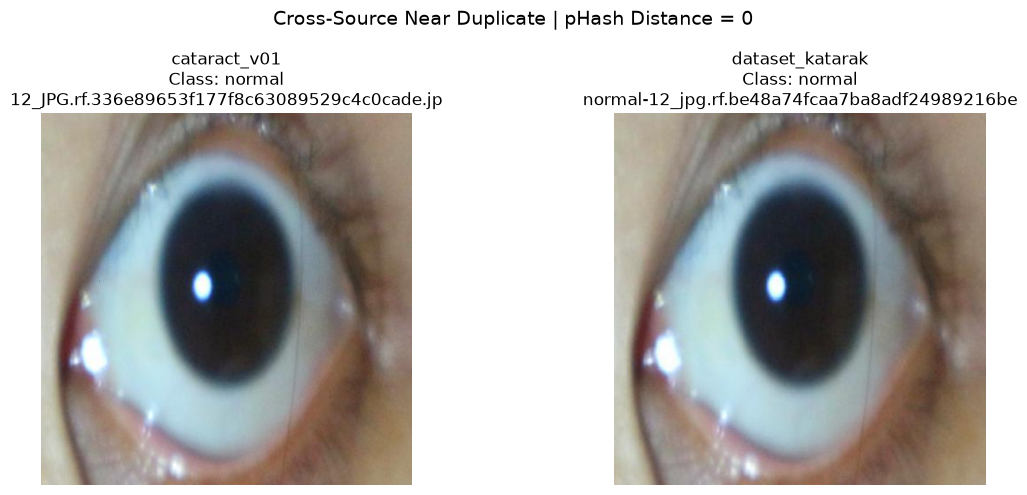

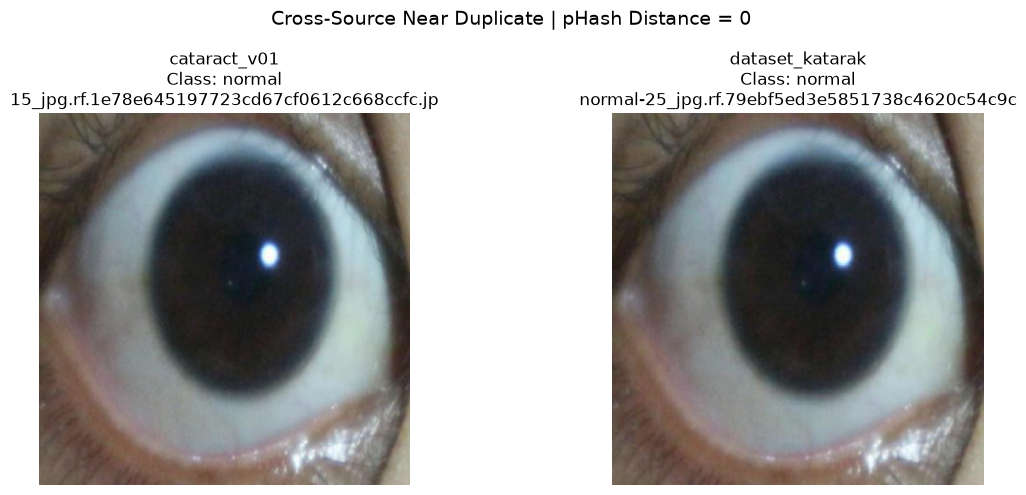

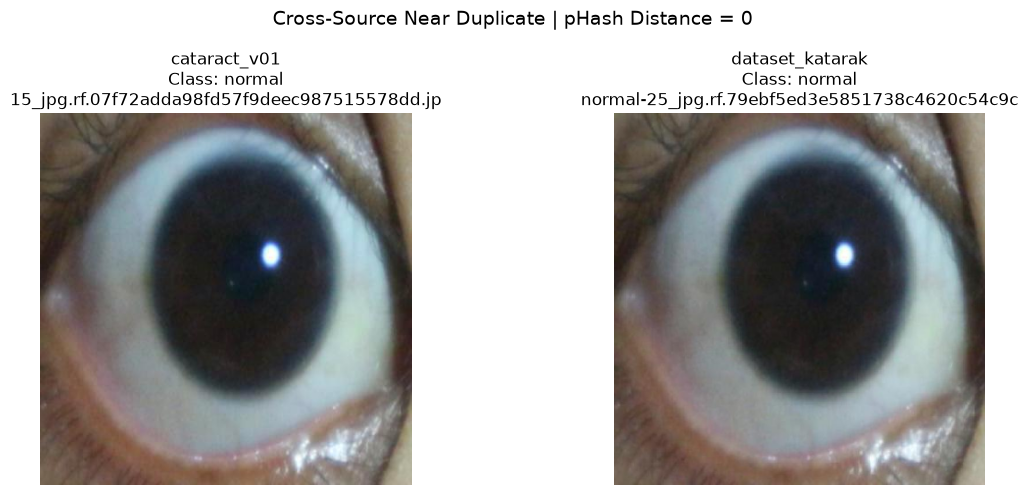

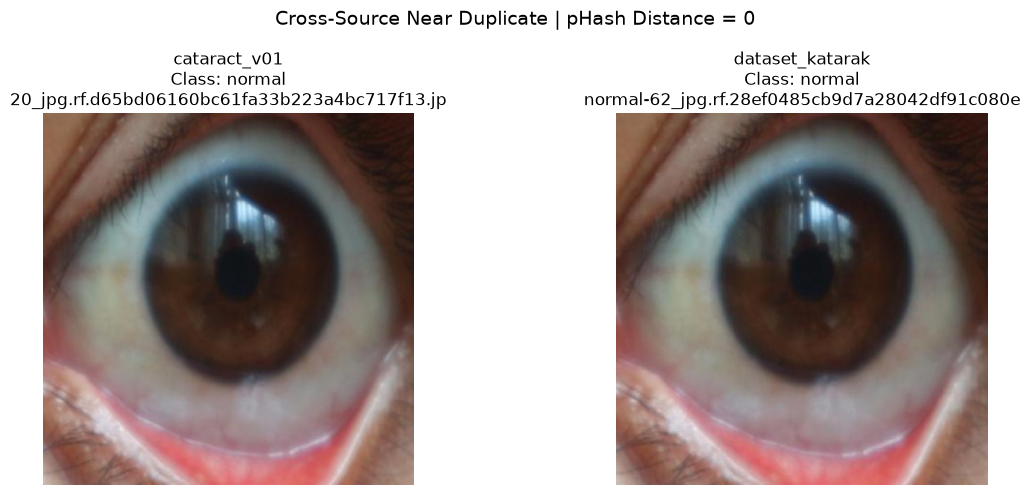

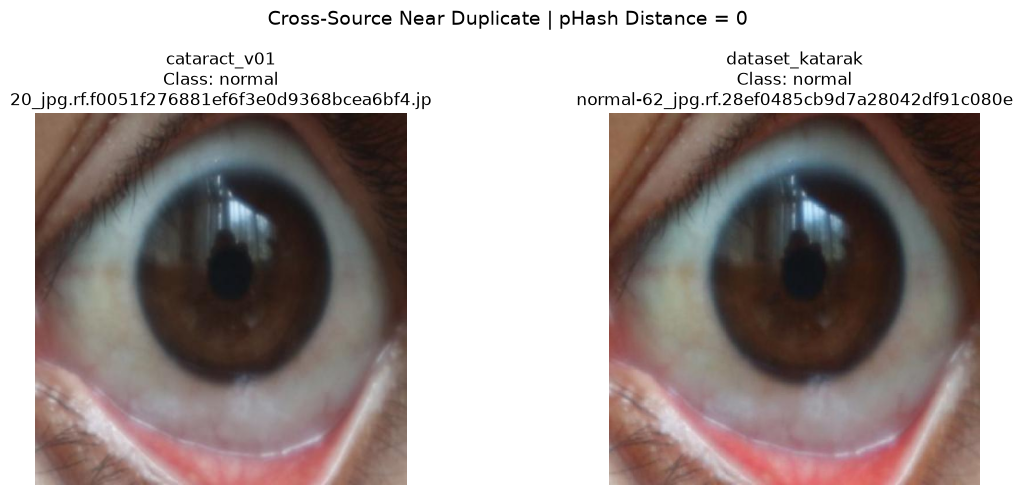

In [8]:
import matplotlib.pyplot as plt
from PIL import Image


def show_pair(row, title="Image Pair"):

    img1 = Image.open(row["path_1"]).convert("RGB")
    img2 = Image.open(row["path_2"]).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img1)
    axes[0].axis("off")
    axes[0].set_title(
        f"{row['source_1']}\n"
        f"Class: {row['class_1']}\n"
        f"{row['filename_1'][:45]}"
    )

    axes[1].imshow(img2)
    axes[1].axis("off")
    axes[1].set_title(
        f"{row['source_2']}\n"
        f"Class: {row['class_2']}\n"
        f"{row['filename_2'][:45]}"
    )

    fig.suptitle(
        f"{title} | pHash Distance = {row['distance']}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 1. LABEL-CONFLICTING PAIR
# ============================================================

print("LABEL-CONFLICTING PAIR")
print("=" * 60)

if len(conflicting_near) > 0:

    for _, row in conflicting_near.iterrows():
        show_pair(
            row,
            "Possible Label Conflict"
        )

else:
    print("No conflicting pairs found.")


# ============================================================
# 2. CROSS-SOURCE NEAR-DUPLICATES
# ============================================================

print("\nCROSS-SOURCE EXAMPLES")
print("=" * 60)

cross_examples = (
    cross_source_near
    .sort_values("distance")
    .head(6)
)

for _, row in cross_examples.iterrows():

    show_pair(
        row,
        "Cross-Source Near Duplicate"
    )

The cross-source pairs are clearly the same underlying eye images appearing in both Cataract v01 and Dataset Katarak. So the overlap is real, not just pHash being overly sensitive.
For the Normal ↔ Immature pair at distance 4, however, I would not call it a duplicate. They look similar in composition, but they are visibly different photographs/eyes. This is a good example of why we should not blindly delete everything with pHash ≤ 4.
So I want to change our strategy slightly:
- pHash = 0: treat as strong duplicate candidates.
- pHash 2–4: don't automatically remove; use them primarily to identify related/augmented groups and prevent leakage.
- Different-label pair at distance 4: keep both unless stronger evidence later shows they're derived from the same original.
- We should prioritize group-aware splitting rather than aggressively deleting valid medical images.

Cataract v01 ── same underlying image ── Dataset Katarak
        ↓                                  ↓
      Train                              Test?
      

If that happened, our test accuracy could become artificially high because the model has effectively already seen that eye.
Next step
Before creating train/validation/test, we need to assign related images a group ID so that all variants of an underlying image are forced into the same split.

many images look heavily transformed/processed already. We therefore need to be conservative with additional augmentation later.

This is Cell 8. It creates visual-family group IDs from the near-duplicate relationships we already calculated. It does not delete, move, or modify any images.
We'll use a Union-Find / Disjoint Set algorithm: if A is related to B, and B is related to C, then A, B, and C belong to the same visual family.

In [9]:
# ============================================================
# CELL 8 — CREATE VISUAL-FAMILY GROUPS
# ============================================================

import pandas as pd
from collections import Counter


# ============================================================
# UNION-FIND / DISJOINT SET
# ============================================================

class UnionFind:

    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):

        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])

        return self.parent[x]

    def union(self, x, y):

        root_x = self.find(x)
        root_y = self.find(y)

        if root_x == root_y:
            return

        if self.rank[root_x] < self.rank[root_y]:

            self.parent[root_x] = root_y

        elif self.rank[root_x] > self.rank[root_y]:

            self.parent[root_y] = root_x

        else:

            self.parent[root_y] = root_x
            self.rank[root_x] += 1


# ============================================================
# CREATE GROUPS
# ============================================================

uf = UnionFind(len(primary))


# IMPORTANT:
# Distance 0 = extremely strong visual duplicate.
#
# We use distance 0 for automatic grouping.
# Distance 2-4 remains flagged for later analysis,
# but is NOT automatically merged yet.

AUTO_GROUP_DISTANCE = 0


strong_duplicate_pairs = near_duplicates_df[
    near_duplicates_df["distance"] <= AUTO_GROUP_DISTANCE
].copy()


print("CREATING VISUAL-FAMILY GROUPS")
print("=" * 60)

print(
    "Pairs used for automatic grouping:",
    len(strong_duplicate_pairs)
)


for _, row in strong_duplicate_pairs.iterrows():

    i = int(row["index_1"])
    j = int(row["index_2"])

    uf.union(i, j)


# ============================================================
# ASSIGN FAMILY IDS
# ============================================================

root_to_family = {}

family_counter = 1

family_ids = []


for i in range(len(primary)):

    root = uf.find(i)

    if root not in root_to_family:

        root_to_family[root] = (
            f"VF_{family_counter:05d}"
        )

        family_counter += 1

    family_ids.append(
        root_to_family[root]
    )


primary["visual_family_id"] = family_ids


# ============================================================
# FAMILY SIZE
# ============================================================

family_sizes = (
    primary["visual_family_id"]
    .value_counts()
)


primary["visual_family_size"] = (
    primary["visual_family_id"]
    .map(family_sizes)
)


# ============================================================
# SUMMARY
# ============================================================

print("\nVISUAL FAMILY SUMMARY")
print("=" * 60)

print(
    "Total images:",
    len(primary)
)

print(
    "Total visual families:",
    primary["visual_family_id"].nunique()
)

print(
    "Single-image families:",
    (family_sizes == 1).sum()
)

print(
    "Multi-image families:",
    (family_sizes > 1).sum()
)

print(
    "Images belonging to multi-image families:",
    primary[
        primary["visual_family_size"] > 1
    ].shape[0]
)

print(
    "Largest visual family:",
    family_sizes.max(),
    "images"
)


# ============================================================
# FAMILY SIZE DISTRIBUTION
# ============================================================

print("\nFAMILY SIZE DISTRIBUTION")
print("=" * 60)

size_distribution = (
    family_sizes
    .value_counts()
    .sort_index()
)

print(size_distribution)


# ============================================================
# CHECK WHETHER ANY FAMILY CONTAINS MULTIPLE CLASSES
# ============================================================

family_class_counts = (
    primary
    .groupby("visual_family_id")["class"]
    .nunique()
)


conflicting_families = (
    family_class_counts[
        family_class_counts > 1
    ]
)


print("\nCLASS CONFLICT CHECK")
print("=" * 60)

print(
    "Families containing multiple class labels:",
    len(conflicting_families)
)


if len(conflicting_families) > 0:

    conflicting_family_data = primary[
        primary["visual_family_id"].isin(
            conflicting_families.index
        )
    ].sort_values(
        "visual_family_id"
    )

    display(
        conflicting_family_data[
            [
                "visual_family_id",
                "source",
                "class",
                "filename",
                "phash",
                "visual_family_size"
            ]
        ]
    )


# ============================================================
# CHECK CROSS-SOURCE FAMILIES
# ============================================================

family_source_counts = (
    primary
    .groupby("visual_family_id")["source"]
    .nunique()
)


cross_source_families = (
    family_source_counts[
        family_source_counts > 1
    ]
)


print("\nCROSS-SOURCE FAMILY CHECK")
print("=" * 60)

print(
    "Families containing images from multiple datasets:",
    len(cross_source_families)
)


# ============================================================
# CLASS-LEVEL FAMILY STATISTICS
# ============================================================

family_class_table = (
    primary
    .groupby("visual_family_id")
    .agg(
        class_name=("class", "first"),
        image_count=("filename", "size"),
        source_count=("source", "nunique")
    )
    .reset_index()
)


print("\nINDEPENDENT VISUAL FAMILIES PER CLASS")
print("=" * 60)

print(
    family_class_table[
        "class_name"
    ].value_counts()
)


# ============================================================
# PREVIEW MULTI-IMAGE FAMILIES
# ============================================================

print("\nEXAMPLE MULTI-IMAGE FAMILIES")
print("=" * 60)


example_family_ids = (
    family_sizes[
        family_sizes > 1
    ]
    .head(10)
    .index
)


example_families = primary[
    primary["visual_family_id"].isin(
        example_family_ids
    )
].sort_values(
    [
        "visual_family_id",
        "source"
    ]
)


display(
    example_families[
        [
            "visual_family_id",
            "visual_family_size",
            "source",
            "original_split",
            "class",
            "filename"
        ]
    ]
)

CREATING VISUAL-FAMILY GROUPS
Pairs used for automatic grouping: 875

VISUAL FAMILY SUMMARY
Total images: 3542
Total visual families: 3127
Single-image families: 2945
Multi-image families: 182
Images belonging to multi-image families: 597
Largest visual family: 9 images

FAMILY SIZE DISTRIBUTION
count
1    2945
2      83
3      22
4      42
5      23
6       5
7       5
8       1
9       1
Name: count, dtype: int64

CLASS CONFLICT CHECK
Families containing multiple class labels: 0

CROSS-SOURCE FAMILY CHECK
Families containing images from multiple datasets: 39

INDEPENDENT VISUAL FAMILIES PER CLASS
class_name
normal      1051
immature    1038
mature      1038
Name: count, dtype: int64

EXAMPLE MULTI-IMAGE FAMILIES


,visual_family_id,visual_family_size,source,original_split,class,filename
184,VF_00080,7,cataract_v01,train,immature,10_JPG.rf.4a82a4b9c83ec4fc9d1852f19e7b1f37.jpg
185,VF_00080,7,cataract_v01,train,immature,10_JPG.rf.f0d99d05644b44745398a2b872a3c326.jpg
186,VF_00080,7,cataract_v01,train,immature,10_JPG_jpg.rf.2bfb6c2bed1d8c13749ca8a545a95c78...
187,VF_00080,7,cataract_v01,train,immature,10_JPG_jpg.rf.79a401a8e8c2563eb8c0f62b15aae622...
188,VF_00080,7,cataract_v01,train,immature,10_JPG_jpg.rf.a5abd8b5985a0c0e0245118f5dd4f3d2...
...,...,...,...,...,...,...
508,VF_00183,7,cataract_v01,train,mature,27_jpg.rf.391207ed639870eb3b87095472e82898.jpg
509,VF_00183,7,cataract_v01,train,mature,27_jpg.rf.3b243a971a75e325914dc65baa868b3b.jpg
510,VF_00183,7,cataract_v01,train,mature,27_jpg.rf.48a52a8d047b43ba309113d3146b0c60.jpg
512,VF_00183,7,cataract_v01,train,mature,27_jpg.rf.ae06d5f32ea9e1f18e7351e0d9fbd5fc.jpg


We now have 3,127 visual families from 3,542 images, with 0 class-conflicting families. The classes are also almost perfectly balanced at the family level: Normal 1,051, Immature 1,038, Mature 1,038. And the 39 cross-source families confirm that our grouping is preventing obvious leakage between Cataract v01 and Katarak.
The next step is to create a family-aware 70/15/15 Train/Validation/Test split. Every image belonging to the same visual family will always stay in the same partition.

In [10]:
#Create clean Train / Val / Test split family aware 

# ============================================================
# CELL 9 — FAMILY-AWARE TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
import pandas as pd


RANDOM_SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15


# ============================================================
# CREATE ONE RECORD PER VISUAL FAMILY
# ============================================================

families = (
    primary
    .groupby("visual_family_id")
    .agg(
        class_name=("class", "first"),
        family_size=("filename", "size")
    )
    .reset_index()
)


print("TOTAL VISUAL FAMILIES:", len(families))

print("\nFamilies per class:")
print(
    families["class_name"].value_counts()
)


# ============================================================
# FIRST SPLIT
# 70% TRAIN
# 30% TEMPORARY
# ============================================================

train_families, temp_families = train_test_split(

    families,

    test_size=(VAL_RATIO + TEST_RATIO),

    random_state=RANDOM_SEED,

    stratify=families["class_name"]
)


# ============================================================
# SECOND SPLIT
# TEMPORARY → 50% VALIDATION / 50% TEST
#
# Because temp = 30%:
#
# 15% validation
# 15% test
# ============================================================

val_families, test_families = train_test_split(

    temp_families,

    test_size=0.50,

    random_state=RANDOM_SEED,

    stratify=temp_families["class_name"]
)


# ============================================================
# CREATE FAMILY → SPLIT MAPPING
# ============================================================

family_to_split = {}


for family_id in train_families["visual_family_id"]:

    family_to_split[family_id] = "train"


for family_id in val_families["visual_family_id"]:

    family_to_split[family_id] = "val"


for family_id in test_families["visual_family_id"]:

    family_to_split[family_id] = "test"


# ============================================================
# APPLY SPLIT TO EVERY IMAGE
# ============================================================

primary["split"] = (
    primary["visual_family_id"]
    .map(family_to_split)
)


# ============================================================
# BASIC CHECK
# ============================================================

print("\n" + "=" * 60)
print("FINAL IMAGE SPLIT")
print("=" * 60)

print(
    primary["split"].value_counts()
)


print("\nPercentage:")

print(
    (
        primary["split"].value_counts(normalize=True)
        * 100
    ).round(2)
)


# ============================================================
# CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION BY SPLIT")
print("=" * 60)

split_class_table = pd.crosstab(

    primary["split"],

    primary["class"]
)

display(split_class_table)


# ============================================================
# FAMILY DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("VISUAL FAMILIES BY SPLIT")
print("=" * 60)

family_split_counts = (

    primary[
        [
            "visual_family_id",
            "split"
        ]
    ]

    .drop_duplicates()

    ["split"]

    .value_counts()
)

print(family_split_counts)


# ============================================================
# CRITICAL LEAKAGE CHECK
# ============================================================

family_split_check = (

    primary
    .groupby("visual_family_id")["split"]
    .nunique()
)


leaking_families = (

    family_split_check[
        family_split_check > 1
    ]
)


print("\n" + "=" * 60)
print("DATA LEAKAGE CHECK")
print("=" * 60)

print(
    "Visual families appearing in multiple splits:",
    len(leaking_families)
)


if len(leaking_families) == 0:

    print("PASS — No visual-family leakage detected.")

else:

    print("WARNING — Leakage detected!")


# ============================================================
# CHECK EACH SPLIT CONTAINS ALL CLASSES
# ============================================================

print("\n" + "=" * 60)
print("CLASS PRESENCE CHECK")
print("=" * 60)


for split_name in ["train", "val", "test"]:

    classes = sorted(

        primary.loc[
            primary["split"] == split_name,
            "class"
        ].unique()

    )

    print(
        f"{split_name.upper():5}: {classes}"
    )


# ============================================================
# PREVIEW FINAL METADATA
# ============================================================

print("\nFINAL DATASET PREVIEW")

display(

    primary[
        [
            "source",
            "filename",
            "class",
            "visual_family_id",
            "visual_family_size",
            "split",
            "image_path"
        ]
    ].head(20)

)



TOTAL VISUAL FAMILIES: 3127

Families per class:
class_name
normal      1051
immature    1038
mature      1038
Name: count, dtype: int64

FINAL IMAGE SPLIT
split
train    2487
val       536
test      519
Name: count, dtype: int64

Percentage:
split
train    70.21
val      15.13
test     14.65
Name: proportion, dtype: float64

CLASS DISTRIBUTION BY SPLIT


class,immature,mature,normal
split,,,
test,180,168,171
train,839,822,826
val,177,187,172



VISUAL FAMILIES BY SPLIT
split
train    2188
test      470
val       469
Name: count, dtype: int64

DATA LEAKAGE CHECK
Visual families appearing in multiple splits: 0
PASS — No visual-family leakage detected.

CLASS PRESENCE CHECK
TRAIN: ['immature', 'mature', 'normal']
VAL  : ['immature', 'mature', 'normal']
TEST : ['immature', 'mature', 'normal']

FINAL DATASET PREVIEW


,source,filename,class,visual_family_id,visual_family_size,split,image_path
0,cataract_v01,10_JPG.rf.4d794597e5e669e1ef983f5a6f35c7be.jpg,normal,VF_00001,4,train,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...
1,cataract_v01,10_JPG.rf.82653827daeea8d76984332b12542e4c.jpg,normal,VF_00001,4,train,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...
2,cataract_v01,10_JPG_jpg.rf.3a69cc495f501d671f0eabbecb32f1fb...,normal,VF_00002,1,test,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...
3,cataract_v01,10_JPG_jpg.rf.6d4e8477b384db74b247556e1929949e...,normal,VF_00001,4,train,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...
4,cataract_v01,10_JPG_jpg.rf.f685ff537d35a314eafe627abfe5f545...,normal,VF_00001,4,train,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...
5,cataract_v01,11_JPG.rf.012e9da4323b3b425c4ddff190854340.jpg,normal,VF_00003,2,test,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...
6,cataract_v01,11_JPG.rf.bf2fd6d437a787ddc3192912f49f16b7.jpg,normal,VF_00004,2,train,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...
7,cataract_v01,11_JPG_jpg.rf.0c6f778623eadea084efc6bb05816f87...,normal,VF_00005,2,train,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...
8,cataract_v01,11_JPG_jpg.rf.21062af086181fdc1149f3e5b4ab236c...,normal,VF_00003,2,test,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...
9,cataract_v01,11_JPG_jpg.rf.c40ecc148d252c0c619e2d0b9b0bf1d7...,normal,VF_00004,2,train,C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\...


Train	2,487total images	70.21%images immature=839 mature=822	normal=826
Validation	536total images images15.13%	immature=177	mature=187	normal=172
test 519total images 14.65%images immature=180 mature=168 normal = 171

Visual families appearing in multiple splits: 0 — PASS

So obvious duplicate families cannot leak between train/validation/test.
Before training ViT, let's save this split permanently. Otherwise restarting the notebook means rebuilding all of this.

In [11]:
#saving the master 3-class dataset
# ============================================================
# CELL 10 — SAVE FINAL 3-CLASS DATASET MANIFEST
# ============================================================

from pathlib import Path
import pandas as pd


OUTPUT_DIR = ROOT / "NetraScan_Metadata"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# MASTER FILE
# ------------------------------------------------------------

master_columns = [
    "source",
    "original_split",
    "filename",
    "class",
    "image_path",
    "sha256",
    "phash",
    "visual_family_id",
    "visual_family_size",
    "split"
]


final_metadata = primary[
    master_columns
].copy()


MASTER_CSV = OUTPUT_DIR / "netrascan_3class_master.csv"

final_metadata.to_csv(
    MASTER_CSV,
    index=False
)


# ------------------------------------------------------------
# INDIVIDUAL SPLIT FILES
# ------------------------------------------------------------

for split_name in ["train", "val", "test"]:

    split_df = final_metadata[
        final_metadata["split"] == split_name
    ].copy()

    split_path = (
        OUTPUT_DIR /
        f"netrascan_{split_name}.csv"
    )

    split_df.to_csv(
        split_path,
        index=False
    )


# ------------------------------------------------------------
# VERIFY SAVED FILES
# ------------------------------------------------------------

print("NETRASCAN DATASET MANIFEST SAVED")
print("=" * 60)

print("Folder:")
print(OUTPUT_DIR)

print("\nMaster:")
print(MASTER_CSV)

print("\nSaved files:")

for file in sorted(OUTPUT_DIR.glob("*.csv")):

    df_check = pd.read_csv(file)

    print(
        f"{file.name:35} "
        f"{len(df_check):5} rows"
    )


print("\n" + "=" * 60)
print("FINAL DATASET")
print("=" * 60)

print("Classes:")
print(sorted(final_metadata["class"].unique()))

print("\nTotal images:", len(final_metadata))

print("\nSplit:")
print(final_metadata["split"].value_counts())

print("\nREADY FOR MODEL TRAINING.")

NETRASCAN DATASET MANIFEST SAVED
Folder:
C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\MY PROJECT E PAARVAI\NetraScan_Metadata

Master:
C:\Personal AI & ML PROJECTS\AI IN HEALTHCARE\MY PROJECT E PAARVAI\NetraScan_Metadata\netrascan_3class_master.csv

Saved files:
netrascan_3class_master.csv          3542 rows
netrascan_test.csv                    519 rows
netrascan_train.csv                  2487 rows
netrascan_val.csv                     536 rows

FINAL DATASET
Classes:
['immature', 'mature', 'normal']

Total images: 3542

Split:
split
train    2487
val       536
test      519
Name: count, dtype: int64

READY FOR MODEL TRAINING.


So, till here I built a multi-source dataset pipeline for anterior-eye cataract classification. I first standardized metadata and audited approximately 6,100 images from three sources. I performed SHA-256 exact-duplicate detection followed by perceptual-hash analysis, which revealed visual overlap between two datasets despite there being no byte-identical files. I then used Union-Find to construct visual-family groups and performed a stratified family-aware train/validation/test split, ensuring related image variants could not cross dataset partitions. This resulted in 3,542 three-class samples with zero detected visual-family leakage.